In [1]:
!pip install torch torchvision
!pip install opencv-python matplotlib
!pip install git+https://github.com/facebookresearch/segment-anything.git
!pip install transformers
!pip install albumentations

  Cloning https://github.com/facebookresearch/segment-anything.git to /tmp/pip-req-build-7kxczied
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/segment-anything.git /tmp/pip-req-build-7kxczied
  Resolved https://github.com/facebookresearch/segment-anything.git to commit dca509fe793f601edb92606367a655c15ac00fdf
  Preparing metadata (setup.py) ... done
  Created wheel for segment_anything: filename=segment_anything-1.0-py3-none-any.whl size=36592 sha256=6e1377855277e54b6715f360de92c8e7e6f61f78a99c53195c742b992ff6f4f0
  Stored in directory: /tmp/pip-ephem-wheel-cache-r6t__4rx/wheels/29/82/ff/04e2be9805a1cb48bec0b85b5a6da6b63f647645750a0e42d4
Successfully built segment_anything


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt
from tqdm import tqdm
import urllib.request
import albumentations as A
from albumentations.pytorch import ToTensorV2
from segment_anything import sam_model_registry
from torch.optim import AdamW

print("Imports successful!")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

Imports successful!
PyTorch version: 2.10.0+cpu
CUDA available: False


In [3]:
# Download SAM checkpoint
checkpoint_url = "https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth"
checkpoint_path = "sam_vit_b_01ec64.pth"

if not os.path.exists(checkpoint_path):
    print("Downloading SAM checkpoint...")
    urllib.request.urlretrieve(checkpoint_url, checkpoint_path)
    print(f"Download complete! Saved to: {checkpoint_path}")
else:
    print(f"Checkpoint already exists: {checkpoint_path}")

Download complete! Saved to: sam_vit_b_01ec64.pth


In [4]:
# Verify dataset paths
image_dir = '/content/drive/MyDrive/My_dataset/train_image'
mask_dir = '/content/drive/MyDrive/My_dataset/train_mask'

print(f"Image directory exists: {os.path.exists(image_dir)}")
print(f"Mask directory exists: {os.path.exists(mask_dir)}")

# List files
image_files = sorted([f for f in os.listdir(image_dir) if f.endswith('.png')])
mask_files = sorted([f for f in os.listdir(mask_dir) if f.endswith('.png')])

print(f"\nFirst 5 image files: {image_files[:5]}")
print(f"Total image files: {len(image_files)}")
print(f"\nFirst 5 mask files: {mask_files[:5]}")
print(f"Total mask files: {len(mask_files)}")

# Check if files match
if image_files == mask_files:
    print("\n✓ Image and mask files match!")
else:
    print("\n⚠ Warning: Image and mask files don't match exactly")

# Sample inspection
sample_img = cv2.imread(os.path.join(image_dir, image_files[0]))
sample_mask = cv2.imread(os.path.join(mask_dir, mask_files[0]), cv2.IMREAD_GRAYSCALE)

print(f"\nSample image shape: {sample_img.shape}")
print(f"Sample mask shape: {sample_mask.shape}")
print(f"Mask unique values: {np.unique(sample_mask)}")

Image directory exists: True
Mask directory exists: True

First 5 image files: ['03afaa9b-image_0422.png', '03bc8501-image_1249.png', '03ea2dc1-image_1207.png', '047f7fee-image_0874.png', '04880b7e-image_0404.png']
Total image files: 1865

First 5 mask files: ['03afaa9b-image_0422.png', '03bc8501-image_1249.png', '03ea2dc1-image_1207.png', '047f7fee-image_0874.png', '04880b7e-image_0404.png']
Total mask files: 1865

✓ Image and mask files match!

Sample image shape: (512, 512, 3)
Sample mask shape: (512, 512)
Mask unique values: [0 1]


In [8]:
class SimpleCoconutDataset:
    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.transform = transform

        # Get sorted files
        self.image_files = sorted([f for f in os.listdir(image_dir) if f.endswith('.png')])

        # Verify all masks exist
        self.valid_files = []
        for img_file in self.image_files:
            mask_path = os.path.join(mask_dir, img_file)
            if os.path.exists(mask_path):
                self.valid_files.append(img_file)

        print(f"Found {len(self.valid_files)} valid image-mask pairs")

    def __len__(self):
        return len(self.valid_files)

    def __getitem__(self, idx):
        img_file = self.valid_files[idx]

        # Load image
        img_path = os.path.join(self.image_dir, img_file)
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Load mask
        mask_path = os.path.join(self.mask_dir, img_file)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        # Make mask binary (0, 1)
        mask = (mask > 0).astype(np.float32)

        # Get bounding box from mask
        pos = np.where(mask > 0)
        if len(pos[0]) > 0 and len(pos[1]) > 0:
            x_min, x_max = np.min(pos[1]), np.max(pos[1])
            y_min, y_max = np.min(pos[0]), np.max(pos[0])

            # Add padding
            padding = 10
            x_min = max(0, x_min - padding)
            y_min = max(0, y_min - padding)
            x_max = min(image.shape[1], x_max + padding)
            y_max = min(image.shape[0], y_max + padding)
            bbox = [x_min, y_min, x_max, y_max]
        else:
            bbox = [0, 0, image.shape[1], image.shape[0]]

        # Apply transform if provided
        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']

            # Ensure mask has channel dimension
            if len(mask.shape) == 2:
                mask = mask.unsqueeze(0)

        return {
            'image': image,
            'mask': mask,
            'bbox': torch.tensor(bbox, dtype=torch.float32),
            'image_name': img_file
        }

# Test the dataset
print("Testing dataset...")
test_transform = A.Compose([
    A.Resize(1024, 1024),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

test_dataset = SimpleCoconutDataset(image_dir, mask_dir, transform=test_transform)
sample = test_dataset[0]
print(f"Sample keys: {list(sample.keys())}")
print(f"Image shape: {sample['image'].shape}")
print(f"Mask shape: {sample['mask'].shape}")
print(f"Bbox: {sample['bbox']}")
print("✓ Dataset test successful!")

Testing dataset...
Found 1865 valid image-mask pairs
Sample keys: ['image', 'mask', 'bbox', 'image_name']
Image shape: torch.Size([3, 1024, 1024])
Mask shape: torch.Size([1, 1024, 1024])
Bbox: tensor([  0.,   0., 512., 460.])
✓ Dataset test successful!


In [7]:
# Define transforms
train_transform = A.Compose([
    A.Resize(1024, 1024),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Resize(1024, 1024),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

# Get all files
all_files = sorted([f for f in os.listdir(image_dir) if f.endswith('.png')])
print(f"Total files: {len(all_files)}")

# Split: 16 train, 4 validation
train_files = all_files[:1492]
val_files = all_files[1492:]

print(f"Training files: {len(train_files)}")
print(f"Validation files: {len(val_files)}")

# Create datasets
train_dataset = SimpleCoconutDataset(image_dir, mask_dir, transform=train_transform)
train_dataset.valid_files = train_files  # Override with training files

val_dataset = SimpleCoconutDataset(image_dir, mask_dir, transform=val_transform)
val_dataset.valid_files = val_files  # Override with validation files

# Create dataloaders
train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=1, shuffle=True, num_workers=0
)

val_loader = torch.utils.data.DataLoader(
    val_dataset, batch_size=1, shuffle=False, num_workers=0
)

print(f"\nTrain batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")

# Test one batch
for batch in train_loader:
    print(f"\nBatch shapes:")
    print(f"  Images: {batch['image'].shape}")
    print(f"  Masks: {batch['mask'].shape}")
    print(f"  Bboxes: {batch['bbox'].shape}")
    break

Total files: 1865
Training files: 1492
Validation files: 373
Found 1865 valid image-mask pairs
Found 1865 valid image-mask pairs

Train batches: 1492
Val batches: 373

Batch shapes:
  Images: torch.Size([1, 3, 1024, 1024])
  Masks: torch.Size([1, 1, 1024, 1024])
  Bboxes: torch.Size([1, 4])


In [15]:
# Initialize SAM model
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

model = sam_model_registry["vit_b"](checkpoint=checkpoint_path)
model.to(device)

# Freeze layers (only train mask decoder)
for param in model.image_encoder.parameters():
    param.requires_grad = True

for param in model.prompt_encoder.parameters():
    param.requires_grad = True

# Only mask decoder is trainable
for param in model.mask_decoder.parameters():
    param.requires_grad = True

print("\nModel architecture:")
print(f"Image encoder frozen: {not any(p.requires_grad for p in model.image_encoder.parameters())}")
print(f"Prompt encoder frozen: {not any(p.requires_grad for p in model.prompt_encoder.parameters())}")
print(f"Mask decoder trainable: {any(p.requires_grad for p in model.mask_decoder.parameters())}")

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,} ({trainable_params/total_params*100:.2f}%)")

Using device: cuda

Model architecture:
Image encoder frozen: False
Prompt encoder frozen: False
Mask decoder trainable: True

Total parameters: 93,735,472
Trainable parameters: 93,735,472 (100.00%)


In [16]:
def compute_loss(pred_masks, gt_masks):
    """
    Combined BCE and Dice loss
    """
    # Binary Cross Entropy
    bce_loss = F.binary_cross_entropy_with_logits(pred_masks, gt_masks)

    # Dice Loss
    pred_sigmoid = torch.sigmoid(pred_masks)
    smooth = 1e-6
    intersection = (pred_sigmoid * gt_masks).sum()
    union = pred_sigmoid.sum() + gt_masks.sum()
    dice_loss = 1 - (2. * intersection + smooth) / (union + smooth)

    # Combined loss
    total_loss = bce_loss + dice_loss

    return total_loss, bce_loss.item(), dice_loss.item()

# Test loss function with dummy data
print("Testing loss function...")
dummy_pred = torch.randn(1, 1, 1024, 1024)
dummy_gt = torch.randint(0, 2, (1, 1, 1024, 1024)).float()
loss, bce, dice = compute_loss(dummy_pred, dummy_gt)
print(f"Test loss - Total: {loss:.4f}, BCE: {bce:.4f}, Dice: {dice:.4f}")

Testing loss function...
Test loss - Total: 1.3061, BCE: 0.8064, Dice: 0.4997


In [17]:
def train_one_batch(model, batch, optimizer, device):
    """Train on a single batch for testing"""
    model.train()

    # Move data to device
    images = batch['image'].to(device)
    masks = batch['mask'].to(device)
    bboxes = batch['bbox'].to(device)

    # Forward pass
    with torch.set_grad_enabled(True):
        # Get image embeddings
        image_embeddings = model.image_encoder(images)

        # Get prompt embeddings from bbox
        sparse_embeddings, dense_embeddings = model.prompt_encoder(
            points=None,
            boxes=bboxes.unsqueeze(1),  # Add batch dimension
            masks=None,
        )

        # Predict masks
        low_res_masks, iou_predictions = model.mask_decoder(
            image_embeddings=image_embeddings,
            image_pe=model.prompt_encoder.get_dense_pe(),
            sparse_prompt_embeddings=sparse_embeddings,
            dense_prompt_embeddings=dense_embeddings,
            multimask_output=False,
        )

        # Post-process masks to original size
        masks_pred = model.postprocess_masks(
            low_res_masks,
            input_size=(1024, 1024),
            original_size=(1024, 1024)
        )

        # Compute loss
        loss, bce_loss, dice_loss = compute_loss(masks_pred, masks)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    return loss.item(), bce_loss, dice_loss

# Test with one batch
print("Testing training on one batch...")

# Get one batch
for batch in train_loader:
    test_batch = batch
    break

# Setup optimizer (only trainable parameters)
optimizer = AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=3e-4
)

# Train on one batch
loss, bce, dice = train_one_batch(model, test_batch, optimizer, device)
print(f"Loss after one batch: {loss:.4f} (BCE: {bce:.4f}, Dice: {dice:.4f})")
print("✓ Single batch training successful!")

Testing training on one batch...
Loss after one batch: 2.0084 (BCE: 1.0877, Dice: 0.9208)
✓ Single batch training successful!


In [18]:
def train_epoch(model, dataloader, optimizer, device, epoch):
    """Train for one epoch"""
    model.train()
    total_loss = 0
    losses = []

    pbar = tqdm(dataloader, desc=f'Epoch {epoch}')
    for batch_idx, batch in enumerate(pbar):
        # Train on batch
        loss, bce, dice = train_one_batch(model, batch, optimizer, device)

        total_loss += loss
        losses.append(loss)

        # Update progress bar
        pbar.set_postfix({
            'loss': f'{loss:.4f}',
            'avg_loss': f'{total_loss/(batch_idx+1):.4f}'
        })

    return total_loss / len(dataloader), losses

def validate(model, dataloader, device):
    """Validate model"""
    model.eval()
    total_iou = 0

    with torch.no_grad():
        for batch in tqdm(dataloader, desc='Validating'):
            images = batch['image'].to(device)
            masks = batch['mask'].to(device)
            bboxes = batch['bbox'].to(device)

            # Forward pass
            image_embeddings = model.image_encoder(images)
            sparse_embeddings, dense_embeddings = model.prompt_encoder(
                points=None,
                boxes=bboxes.unsqueeze(1),
                masks=None,
            )

            low_res_masks, _ = model.mask_decoder(
                image_embeddings=image_embeddings,
                image_pe=model.prompt_encoder.get_dense_pe(),
                sparse_prompt_embeddings=sparse_embeddings,
                dense_prompt_embeddings=dense_embeddings,
                multimask_output=False,
            )

            masks_pred = model.postprocess_masks(
                low_res_masks,
                input_size=(1024, 1024),
                original_size=(1024, 1024)
            )

            # Calculate IoU
            pred_binary = (torch.sigmoid(masks_pred) > 0.5).float()
            intersection = (pred_binary * masks).sum()
            union = (pred_binary + masks).clamp(0, 1).sum()
            iou = (intersection + 1e-6) / (union + 1e-6)
            total_iou += iou.item()

    return total_iou / len(dataloader)

print("Training functions defined successfully!")

Training functions defined successfully!


In [19]:
def main_training(num_epochs=10):
    """Main training function"""
    print("Starting training...")

    # Setup optimizer
    optimizer = AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=3e-4,
        weight_decay=1e-4
    )

    # Track history
    history = {
        'train_loss': [],
        'val_iou': [],
        'epoch_losses': []
    }

    best_iou = 0

    for epoch in range(1, num_epochs + 1):
        print(f"\n{'='*60}")
        print(f"Epoch {epoch}/{num_epochs}")
        print(f"{'='*60}")

        # Train
        avg_loss, epoch_losses = train_epoch(model, train_loader, optimizer, device, epoch)
        history['train_loss'].append(avg_loss)
        history['epoch_losses'].extend(epoch_losses)

        # Validate
        if len(val_loader) > 0:
            val_iou = validate(model, val_loader, device)
            history['val_iou'].append(val_iou)

            print(f"\nEpoch {epoch} Summary:")
            print(f"  Train Loss: {avg_loss:.4f}")
            print(f"  Val IoU: {val_iou:.4f}")

            # Save best model
            if val_iou > best_iou:
                best_iou = val_iou
                torch.save({
                    'epoch': epoch,
                    'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'loss': avg_loss,
                    'iou': val_iou,
                }, 'best_coconut_sam.pth')
                print(f"  ✓ Saved best model (IoU: {val_iou:.4f})")
        else:
            print(f"\nEpoch {epoch} - Train Loss: {avg_loss:.4f}")

        # Save checkpoint every 2 epochs
        if epoch % 2 == 0:
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'loss': avg_loss,
                'iou': val_iou if 'val_iou' in locals() else 0,
            }, f'checkpoint_epoch_{epoch}.pth')
            print(f"  ✓ Saved checkpoint")

    # Plot training history
    plot_training_history(history)

    return history

def plot_training_history(history):
    """Plot training curves"""
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Training loss per epoch
    axes[0].plot(history['train_loss'])
    axes[0].set_title('Training Loss per Epoch')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].grid(True)

    # Validation IoU
    if history['val_iou']:
        axes[1].plot(history['val_iou'])
        axes[1].set_title('Validation IoU per Epoch')
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('IoU')
        axes[1].grid(True)

    # Batch losses (smoothed)
    if history['epoch_losses']:
        window_size = max(1, len(history['epoch_losses']) // 20)
        smoothed = np.convolve(history['epoch_losses'],
                              np.ones(window_size)/window_size,
                              mode='valid')
        axes[2].plot(smoothed)
        axes[2].set_title(f'Batch Losses (Smoothed, window={window_size})')
        axes[2].set_xlabel('Batch')
        axes[2].set_ylabel('Loss')
        axes[2].grid(True)

    plt.tight_layout()
    plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
    plt.show()

print("Training setup complete!")

Training setup complete!


In [ ]:
# Start training with 5 epochs first
print("Starting training with 5 epochs...")
history = main_training(num_epochs=30)

print("\nTraining completed!")
print(f"Final training loss: {history['train_loss'][-1]:.4f}")
if history['val_iou']:
    print(f"Best validation IoU: {max(history['val_iou']):.4f}")

Starting training with 5 epochs...
Starting training...

Epoch 1/30


Validating:  24%|██▎       | 88/373 [00:51<02:47,  1.70it/s]


Testing inference...
Loaded model from best_coconut_sam.pth
Epoch: 29, Loss: 0.7390


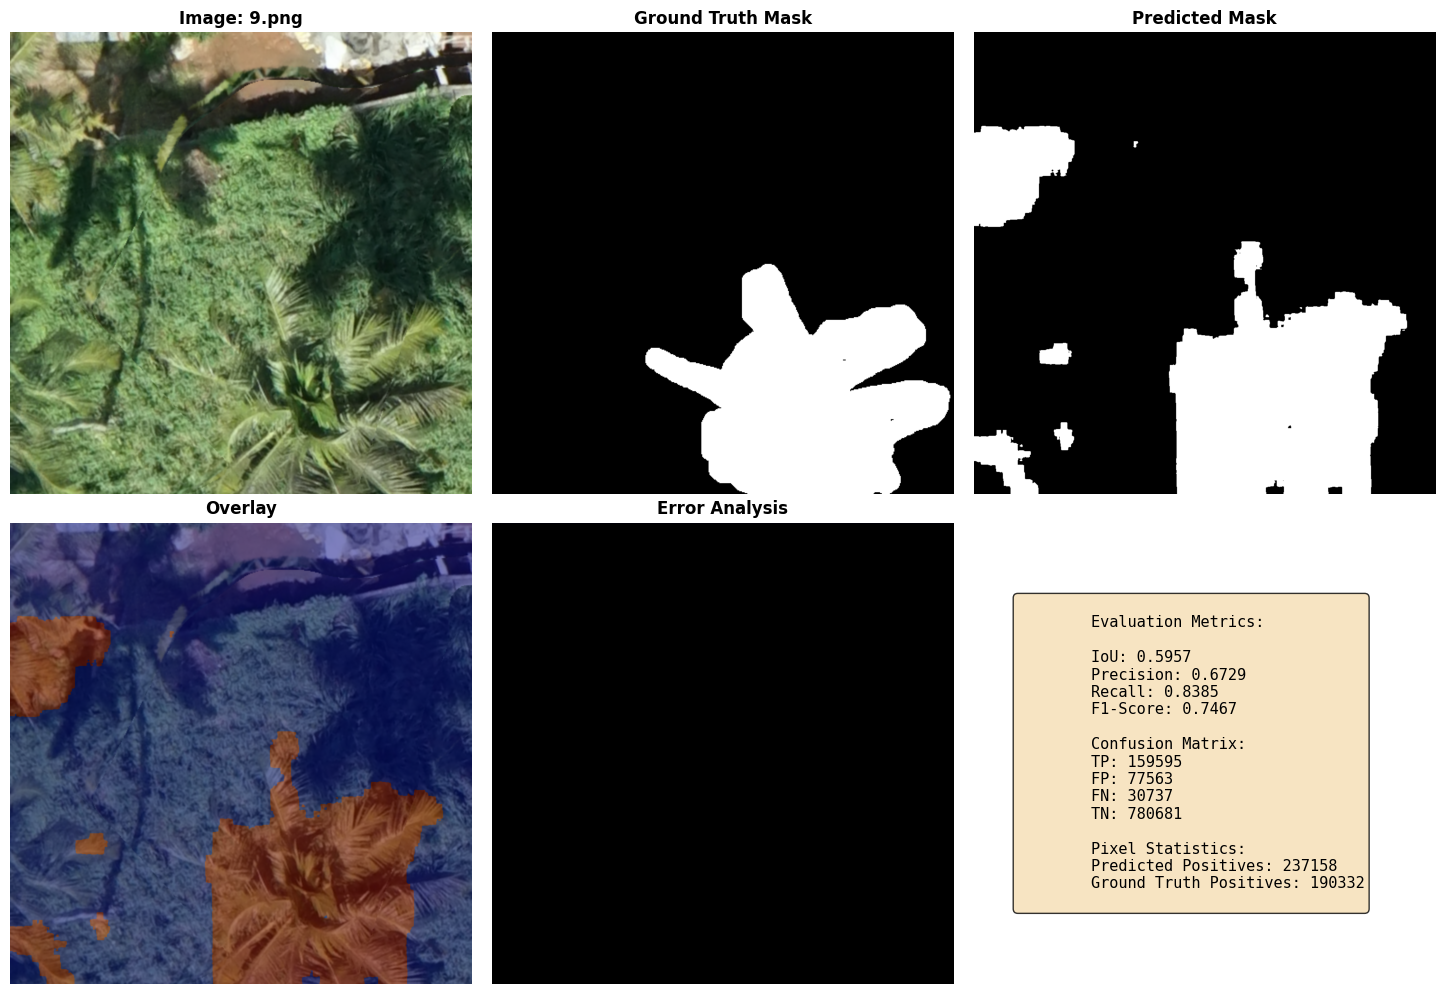


Detailed Results:
IoU: 0.5957
Precision: 0.6729
Recall: 0.8385
F1-Score: 0.7467
True Positive: 159595
False Positive: 77563
False Negative: 30737

✓ Inference test successful!
✓ IoU: 0.5957 (59.6%)


In [ ]:
def test_inference(model_path='best_coconut_sam.pth'):
    """Test inference on a sample image"""
    print("\nTesting inference...")

    # Load trained model
    if os.path.exists(model_path):
        checkpoint = torch.load(model_path, map_location=device)
        model.load_state_dict(checkpoint['model_state_dict'])
        print(f"Loaded model from {model_path}")
        print(f"Epoch: {checkpoint['epoch']}, Loss: {checkpoint['loss']:.4f}")
    else:
        print("Using current model state")

    model.eval()

    # Get a sample from validation set
    for batch in val_loader:
        sample = batch
        #break

    with torch.no_grad():
        images = sample['image'].to(device)
        masks = sample['mask'].to(device)
        bboxes = sample['bbox'].to(device)
        image_name = sample['image_name'][0]

        # Forward pass
        image_embeddings = model.image_encoder(images)
        sparse_embeddings, dense_embeddings = model.prompt_encoder(
            points=None,
            boxes=bboxes.unsqueeze(1),
            masks=None,
        )

        low_res_masks, iou_pred = model.mask_decoder(
            image_embeddings=image_embeddings,
            image_pe=model.prompt_encoder.get_dense_pe(),
            sparse_prompt_embeddings=sparse_embeddings,
            dense_prompt_embeddings=dense_embeddings,
            multimask_output=False,
        )

        masks_pred = model.postprocess_masks(
            low_res_masks,
            input_size=(1024, 1024),
            original_size=(1024, 1024)
        )

        # Convert to numpy
        pred_mask = (torch.sigmoid(masks_pred) > 0.5).cpu().numpy()[0, 0]
        gt_mask = masks.cpu().numpy()[0, 0]
        image_np = images.cpu().numpy()[0].transpose(1, 2, 0)

        # Convert boolean to int for bitwise operations
        pred_mask_int = pred_mask.astype(np.uint8)
        gt_mask_int = gt_mask.astype(np.uint8)

        # Denormalize image for display
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        image_np = image_np * std + mean
        image_np = np.clip(image_np, 0, 1)

        # Calculate IoU
        intersection = np.logical_and(pred_mask_int, gt_mask_int).sum()
        union = np.logical_or(pred_mask_int, gt_mask_int).sum()
        iou = intersection / union if union > 0 else 0

        # Calculate additional metrics
        true_positive = intersection
        false_positive = np.logical_and(pred_mask_int, 1 - gt_mask_int).sum()
        false_negative = np.logical_and(1 - pred_mask_int, gt_mask_int).sum()
        true_negative = np.logical_and(1 - pred_mask_int, 1 - gt_mask_int).sum()

        precision = true_positive / (true_positive + false_positive + 1e-6)
        recall = true_positive / (true_positive + false_negative + 1e-6)
        f1_score = 2 * (precision * recall) / (precision + recall + 1e-6)

        # Visualize
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))

        # Row 1
        axes[0, 0].imshow(image_np)
        axes[0, 0].set_title(f'Image: {image_name}', fontsize=12, fontweight='bold')
        axes[0, 0].axis('off')

        axes[0, 1].imshow(gt_mask, cmap='gray')
        axes[0, 1].set_title('Ground Truth Mask', fontsize=12, fontweight='bold')
        axes[0, 1].axis('off')

        axes[0, 2].imshow(pred_mask, cmap='gray')
        axes[0, 2].set_title(f'Predicted Mask', fontsize=12, fontweight='bold')
        axes[0, 2].axis('off')

        # Row 2
        axes[1, 0].imshow(image_np)
        axes[1, 0].imshow(pred_mask, alpha=0.5, cmap='jet')
        axes[1, 0].set_title('Overlay', fontsize=12, fontweight='bold')
        axes[1, 0].axis('off')

        # Error visualization
        error_mask = np.zeros((*pred_mask.shape, 3), dtype=np.uint8)

        # True positives (green)
        error_mask[pred_mask_int & gt_mask_int] = [0, 255, 0]
        # False positives (red) - predicted but not in ground truth
        error_mask[pred_mask_int & (1 - gt_mask_int)] = [255, 0, 0]
        # False negatives (blue) - in ground truth but not predicted
        error_mask[(1 - pred_mask_int) & gt_mask_int] = [0, 0, 255]

        axes[1, 1].imshow(error_mask)
        axes[1, 1].set_title('Error Analysis', fontsize=12, fontweight='bold')
        axes[1, 1].axis('off')

        # Metrics text
        axes[1, 2].axis('off')
        metrics_text = f"""
        Evaluation Metrics:

        IoU: {iou:.4f}
        Precision: {precision:.4f}
        Recall: {recall:.4f}
        F1-Score: {f1_score:.4f}

        Confusion Matrix:
        TP: {true_positive}
        FP: {false_positive}
        FN: {false_negative}
        TN: {true_negative}

        Pixel Statistics:
        Predicted Positives: {pred_mask_int.sum()}
        Ground Truth Positives: {gt_mask_int.sum()}
        """

        axes[1, 2].text(0.1, 0.5, metrics_text,
                       fontsize=11,
                       fontfamily='monospace',
                       verticalalignment='center',
                       bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

        plt.tight_layout()
        plt.show()

        print(f"\nDetailed Results:")
        print(f"IoU: {iou:.4f}")
        print(f"Precision: {precision:.4f}")
        print(f"Recall: {recall:.4f}")
        print(f"F1-Score: {f1_score:.4f}")
        print(f"True Positive: {true_positive}")
        print(f"False Positive: {false_positive}")
        print(f"False Negative: {false_negative}")

        return iou, precision, recall, f1_score

# Run inference test
if len(val_loader) > 0:
    iou, precision, recall, f1 = test_inference()
    print(f"\n✓ Inference test successful!")
    print(f"✓ IoU: {iou:.4f} ({iou*100:.1f}%)")
else:
    print("No validation data available for inference test")

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader  # Add this import!
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt
from tqdm import tqdm
import albumentations as A
from albumentations.pytorch import ToTensorV2
from segment_anything import sam_model_registry
import pandas as pd
import shutil
import tempfile

print("All imports successful!")

All imports successful!


In [ ]:
class TestCoconutDataset(Dataset):
    def __init__(self, test_image_dir, transform=None):
        """
        Test dataset (no masks required for inference)

        Args:
            test_image_dir: Directory containing test images
            transform: Transformations to apply
        """
        self.test_image_dir = test_image_dir
        self.transform = transform

        # Get all image files
        self.image_files = sorted([f for f in os.listdir(test_image_dir)
                                 if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff'))])

        print(f"Found {len(self.image_files)} test images in {test_image_dir}")
        if self.image_files:
            print(f"Sample files: {self.image_files[:5]}")
        else:
            print("⚠ No images found! Check the directory path and file extensions.")

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_file = self.image_files[idx]
        img_path = os.path.join(self.test_image_dir, img_file)

        # Load image
        image = cv2.imread(img_path)
        if image is None:
            raise ValueError(f"Could not load image: {img_path}")

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        original_size = image.shape[:2]  # (height, width)

        # Apply transform if provided
        if self.transform:
            transformed = self.transform(image=image)
            image = transformed['image']

        return {
            'image': image,
            'original_size': torch.tensor(original_size),
            'image_path': img_path,
            'image_name': img_file
        }

# Test the dataset class
print("Test dataset class defined successfully!")

Test dataset class defined successfully!


In [ ]:
def predict_on_test_set(test_dir, model_path='best_coconut_sam.pth', output_dir='test_predictions'):
    """
    Run inference on a test dataset

    Args:
        test_dir: Directory containing test images
        model_path: Path to trained model
        output_dir: Directory to save predictions
    """
    print(f"\n{'='*60}")
    print(f"TESTING ON NEW DATASET")
    print(f"{'='*60}")
    print(f"Test directory: {test_dir}")
    print(f"Model: {model_path}")
    print(f"Output directory: {output_dir}")

    # Check if test directory exists
    if not os.path.exists(test_dir):
        print(f"❌ Test directory not found: {test_dir}")
        return None

    # Create output directory
    os.makedirs(output_dir, exist_ok=True)
    os.makedirs(os.path.join(output_dir, 'masks'), exist_ok=True)
    os.makedirs(os.path.join(output_dir, 'overlays'), exist_ok=True)
    os.makedirs(os.path.join(output_dir, 'visualizations'), exist_ok=True)

    # Setup device
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(f"Using device: {device}")

    # Load model
    model = sam_model_registry["vit_b"](checkpoint=None)

    if os.path.exists(model_path):
        try:
            checkpoint = torch.load(model_path, map_location=device)
            model.load_state_dict(checkpoint['model_state_dict'])
            print(f"✓ Loaded model from {model_path}")
            if 'epoch' in checkpoint:
                print(f"  Trained for {checkpoint['epoch']} epochs")
                if 'iou' in checkpoint:
                    print(f"  Best IoU: {checkpoint['iou']:.4f}")
        except Exception as e:
            print(f"❌ Error loading model: {e}")
            return None
    else:
        print(f"❌ Model not found at {model_path}")
        print("Available .pth files:")
        for f in os.listdir('.'):
            if f.endswith('.pth'):
                print(f"  - {f}")
        return None

    model.to(device)
    model.eval()

    # Define transform (same as training)
    test_transform = A.Compose([
        A.Resize(1024, 1024),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2(),
    ])

    # Create test dataset
    try:
        test_dataset = TestCoconutDataset(test_dir, transform=test_transform)
    except Exception as e:
        print(f"❌ Error creating dataset: {e}")
        return None

    if len(test_dataset) == 0:
        print("❌ No images found in test directory")
        return None

    test_loader = DataLoader(
        test_dataset, batch_size=1, shuffle=False, num_workers=0
    )

    results = []

    print(f"\nProcessing {len(test_dataset)} images...")
    with torch.no_grad():
        for batch_idx, batch in enumerate(tqdm(test_loader, desc="Processing images")):
            try:
                images = batch['image'].to(device)
                original_sizes = batch['original_size']
                image_paths = batch['image_path']
                image_names = batch['image_name']

                # Get image dimensions for prompts
                _, _, h, w = images.shape  # Batch size, channels, height, width

                # Create point prompts (multiple points for better results)
                points_list = []
                labels_list = []

                # Center point
                points_list.append([w//2, h//2])
                labels_list.append(1)  # Foreground

                # Additional points (strategically placed)
                offsets = [(0.3, 0.3), (0.3, -0.3), (-0.3, 0.3), (-0.3, -0.3)]
                for dx, dy in offsets:
                    points_list.append([int(w//2 + dx * w//4), int(h//2 + dy * h//4)])
                    labels_list.append(1)

                # Convert to tensors
                points_tensor = torch.tensor(points_list, dtype=torch.float32).unsqueeze(0).to(device)
                labels_tensor = torch.tensor(labels_list, dtype=torch.int32).unsqueeze(0).to(device)

                # Get image embeddings
                image_embeddings = model.image_encoder(images)

                # Get prompt embeddings
                sparse_embeddings, dense_embeddings = model.prompt_encoder(
                    points=(points_tensor, labels_tensor),
                    boxes=None,
                    masks=None,
                )

                # Get multiple masks and choose best one
                low_res_masks, iou_predictions = model.mask_decoder(
                    image_embeddings=image_embeddings,
                    image_pe=model.prompt_encoder.get_dense_pe(),
                    sparse_prompt_embeddings=sparse_embeddings,
                    dense_prompt_embeddings=dense_embeddings,
                    multimask_output=True,  # Get 3 masks
                )

                # Choose best mask based on IoU prediction
                best_mask_idx = torch.argmax(iou_predictions[0]).item()
                low_res_mask = low_res_masks[:, best_mask_idx:best_mask_idx+1, :, :]

                # Post-process to original size
                original_h, original_w = original_sizes[0].tolist()
                mask_pred = model.postprocess_masks(
                    low_res_mask,
                    input_size=(1024, 1024),
                    original_size=(original_h, original_w)
                )

                # Convert to probability and binary mask
                mask_prob = torch.sigmoid(mask_pred)[0, 0].cpu().numpy()
                binary_mask = (mask_prob > 0.5).astype(np.uint8) * 255

                # Load original image for visualization
                original_image = cv2.imread(image_paths[0])
                if original_image is None:
                    print(f"⚠ Could not load original image: {image_paths[0]}")
                    continue

                original_image_rgb = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)

                # Calculate coconut area
                coconut_pixels = np.sum(binary_mask > 0)
                total_pixels = binary_mask.shape[0] * binary_mask.shape[1]
                coconut_percentage = (coconut_pixels / total_pixels) * 100

                # Save results
                result = {
                    'image_name': image_names[0],
                    'image_path': image_paths[0],
                    'coconut_pixels': int(coconut_pixels),
                    'total_pixels': int(total_pixels),
                    'percentage': float(coconut_percentage),
                    'mask_prob_mean': float(mask_prob.mean()),
                    'mask_prob_max': float(mask_prob.max()),
                    'iou_confidence': float(iou_predictions[0, best_mask_idx].item())
                }
                results.append(result)

                # Save mask
                base_name = os.path.splitext(image_names[0])[0]
                mask_filename = f"{base_name}_mask.png"
                mask_path = os.path.join(output_dir, 'masks', mask_filename)
                cv2.imwrite(mask_path, binary_mask)

                # Create and save overlay
                overlay = original_image.copy()
                # Create colored mask (red for coconut)
                colored_mask = np.zeros_like(overlay)
                colored_mask[binary_mask > 0] = [0, 0, 255]  # Red in BGR

                # Blend overlay
                overlay = cv2.addWeighted(overlay, 0.7, colored_mask, 0.3, 0)

                overlay_filename = f"{base_name}_overlay.png"
                overlay_path = os.path.join(output_dir, 'overlays', overlay_filename)
                cv2.imwrite(overlay_path, overlay)

                # Create visualization for first 5 images
                if batch_idx < 5:
                    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

                    # Original image
                    axes[0].imshow(original_image_rgb)
                    axes[0].set_title(f'Original\n{image_names[0]}', fontsize=10)
                    axes[0].axis('off')

                    # Mask
                    axes[1].imshow(binary_mask, cmap='gray')
                    axes[1].set_title(f'Prediction\n{coconut_pixels:,} pixels\n({coconut_percentage:.1f}%)', fontsize=10)
                    axes[1].axis('off')

                    # Overlay
                    axes[2].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
                    axes[2].set_title('Overlay', fontsize=10)
                    axes[2].axis('off')

                    plt.tight_layout()
                    viz_path = os.path.join(output_dir, 'visualizations', f'{base_name}_viz.png')
                    plt.savefig(viz_path, dpi=150, bbox_inches='tight')
                    plt.show()

            except Exception as e:
                print(f"\n⚠ Error processing image {batch_idx}: {e}")
                continue

    # Generate summary report
    if results:
        print(f"\n{'='*60}")
        print("TEST RESULTS SUMMARY")
        print(f"{'='*60}")

        total_coconut_pixels = sum(r['coconut_pixels'] for r in results)
        avg_percentage = np.mean([r['percentage'] for r in results])
        avg_iou_confidence = np.mean([r['iou_confidence'] for r in results])

        print(f"\n✓ Processed {len(results)} images successfully")
        print(f"✓ Total coconut pixels detected: {total_coconut_pixels:,}")
        print(f"✓ Average coconut percentage: {avg_percentage:.2f}%")
        print(f"✓ Average IoU confidence: {avg_iou_confidence:.3f}")

        # Save results as CSV
        df_results = pd.DataFrame(results)
        csv_path = os.path.join(output_dir, 'test_results.csv')
        df_results.to_csv(csv_path, index=False)
        print(f"\n✓ Results saved to: {csv_path}")

        # Create histogram of coconut percentages
        plt.figure(figsize=(10, 5))
        percentages = [r['percentage'] for r in results]

        plt.hist(percentages, bins=20, alpha=0.7, color='blue', edgecolor='black')
        plt.xlabel('Coconut Percentage (%)', fontsize=12)
        plt.ylabel('Number of Images', fontsize=12)
        plt.title(f'Distribution of Coconut Coverage (n={len(results)})', fontsize=14, fontweight='bold')
        plt.grid(True, alpha=0.3)

        # Add vertical line for average
        plt.axvline(avg_percentage, color='red', linestyle='--',
                   label=f'Average: {avg_percentage:.1f}%')
        plt.legend(fontsize=11)

        hist_path = os.path.join(output_dir, 'percentage_distribution.png')
        plt.savefig(hist_path, dpi=150, bbox_inches='tight')
        plt.show()

        print(f"\n✓ Output files saved to: {output_dir}/")
        print(f"  ├─ Masks: {output_dir}/masks/")
        print(f"  ├─ Overlays: {output_dir}/overlays/")
        print(f"  ├─ Visualizations: {output_dir}/visualizations/")
        print(f"  ├─ Results CSV: {csv_path}")
        print(f"  └─ Histogram: {hist_path}")

        # Display top 5 results
        print(f"\nTop 5 images by coconut percentage:")
        df_sorted = df_results.sort_values('percentage', ascending=False).head(5)
        for idx, row in df_sorted.iterrows():
            print(f"  {row['image_name']}: {row['percentage']:.1f}% ({row['coconut_pixels']:,} pixels)")

    else:
        print("\n❌ No results were generated. Check for errors above.")

    return results

In [ ]:
def quick_test_single_image(image_path, model_path='best_coconut_sam.pth'):
    """
    Quick test on a single image
    """
    print(f"\n{'='*60}")
    print(f"QUICK TEST ON SINGLE IMAGE")
    print(f"{'='*60}")
    print(f"Image: {image_path}")

    if not os.path.exists(image_path):
        print(f"❌ Image not found: {image_path}")
        return None

    # Create a temporary test directory
    temp_dir = tempfile.mkdtemp()
    try:
        # Copy image to temp dir
        img_name = os.path.basename(image_path)
        temp_img_path = os.path.join(temp_dir, img_name)
        shutil.copy(image_path, temp_img_path)

        # Run prediction
        results = predict_on_test_set(temp_dir, model_path, output_dir='single_test_results')

        if results:
            print(f"\n{'='*60}")
            print("SINGLE IMAGE RESULTS")
            print(f"{'='*60}")
            result = results[0]
            print(f"✓ Image: {result['image_name']}")
            print(f"✓ Coconut pixels: {result['coconut_pixels']:,}")
            print(f"✓ Total pixels: {result['total_pixels']:,}")
            print(f"✓ Coconut percentage: {result['percentage']:.2f}%")
            print(f"✓ Average mask probability: {result['mask_prob_mean']:.3f}")
            print(f"✓ IoU confidence: {result['iou_confidence']:.3f}")

            # Show the generated files
            print(f"\nGenerated files in 'single_test_results/':")
            if os.path.exists('single_test_results'):
                for root, dirs, files in os.walk('single_test_results'):
                    level = root.replace('single_test_results', '').count(os.sep)
                    indent = ' ' * 2 * level
                    print(f"{indent}{os.path.basename(root)}/")
                    subindent = ' ' * 2 * (level + 1)
                    for file in files[:5]:  # Show first 5 files
                        print(f"{subindent}{file}")
                    if len(files) > 5:
                        print(f"{subindent}... and {len(files)-5} more")

            return result

    except Exception as e:
        print(f"❌ Error during single image test: {e}")
        return None
    finally:
        # Cleanup
        if os.path.exists(temp_dir):
            shutil.rmtree(temp_dir)

    return None

In [ ]:
# ============================================================================
# HOW TO USE: UPDATE THESE PATHS AND RUN THIS BLOCK
# ============================================================================

# 1. Specify your test dataset folder path
test_folder_path = "/content/drive/MyDrive/My_dataset/val_1"  # ← CHANGE THIS!

# 2. Specify which model to use (choose one)
model_to_use = "best_coconut_sam.pth"  # Your trained model

# Available models (check what you have):
available_models = [f for f in os.listdir('.') if f.endswith('.pth')]
print("Available models:")
for model in available_models:
    print(f"  - {model}")

# 3. Choose what to run (uncomment your choice)
print(f"\nTest folder: {test_folder_path}")
print(f"Model: {model_to_use}")

if os.path.exists(test_folder_path):
    # Option A: Test on entire folder
    print("\nOption A: Testing on entire folder...")
    results = predict_on_test_set(
        test_dir=test_folder_path,
        model_path=model_to_use,
        output_dir='test_predictions'
    )

    # Option B: Test on a single image (uncomment and specify image)
    # single_image = "/content/drive/MyDrive/My_test_dataset/sample.jpg"
    # if os.path.exists(single_image):
    #     print(f"\nOption B: Testing single image {single_image}...")
    #     result = quick_test_single_image(single_image, model_to_use)

else:
    print(f"\n❌ Test folder not found: {test_folder_path}")
    print("\nPlease check:")
    print("1. Is the path correct?")
    print("2. Is the folder in your Google Drive?")
    print("3. Did you mount Google Drive?")

    # Mount Google Drive if not already mounted
    if not os.path.exists('/content/drive'):
        print("\nTrying to mount Google Drive...")
        from google.colab import drive
        drive.mount('/content/drive')

        # Check again after mounting
        if os.path.exists(test_folder_path):
            print("✓ Google Drive mounted successfully!")
            print(f"✓ Found test folder: {test_folder_path}")
            results = predict_on_test_set(
                test_dir=test_folder_path,
                model_path=model_to_use,
                output_dir='test_predictions'
            )
        else:
            print("❌ Still can't find test folder after mounting.")
            print("Please check the path and try again.")

Output hidden; open in https://colab.research.google.com to view.